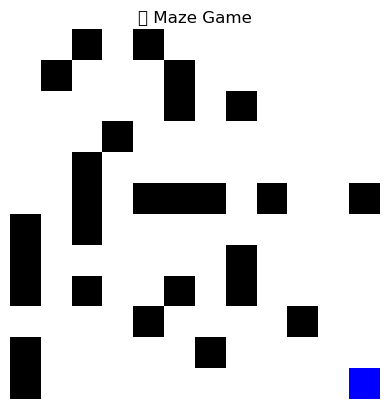

🎉 YOU REACHED THE GOAL!


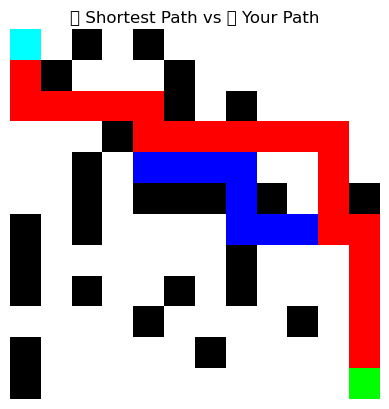

🧠 Algorithm used: BFS
📏 Your path length: 23
⚡ Shortest path length: 23


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from collections import deque
from IPython.display import clear_output

# Maze size
rows, cols = 12, 12

# Generate maze
maze = np.zeros((rows, cols))
for i in range(rows):
    for j in range(cols):
        if random.random() < 0.25:
            maze[i][j] = 1

start = (0, 0)
goal = (rows-1, cols-1)

maze[start] = 0
maze[goal] = 0

player_pos = list(start)
player_path = [start]

# BFS shortest path
def bfs():
    queue = deque([start])
    visited = set([start])
    parent = {}

    while queue:
        x, y = queue.popleft()
        if (x, y) == goal:
            break

        for dx, dy in [(0,1),(1,0),(0,-1),(-1,0)]:
            nx, ny = x+dx, y+dy
            if 0 <= nx < rows and 0 <= ny < cols:
                if maze[nx][ny] == 0 and (nx, ny) not in visited:
                    queue.append((nx, ny))
                    visited.add((nx, ny))
                    parent[(nx, ny)] = (x, y)

    path = []
    node = goal
    while node != start:
        path.append(node)
        node = parent.get(node, start)
    path.append(start)
    path.reverse()
    return path

shortest_path = bfs()

# 🔥 SHOW INITIAL MAZE BEFORE LOOP
grid = np.ones((rows, cols, 3))
for i in range(rows):
    for j in range(cols):
        if maze[i][j] == 1:
            grid[i][j] = [0, 0, 0]

grid[goal] = [0, 1, 0]
grid[player_pos[0]][player_pos[1]] = [0, 0, 1]

plt.imshow(grid)
plt.title("🧩 Maze Game - Start")
plt.axis('off')
plt.show()

print("Controls: w=up, s=down, a=left, d=right")

# 🎮 GAME LOOP
while True:
    
    move = input("Enter move: ").strip().lower()

    dx, dy = 0, 0
    if move == 'w': dx = -1
    elif move == 's': dx = 1
    elif move == 'a': dy = -1
    elif move == 'd': dy = 1
    else:
        continue

    nx = player_pos[0] + dx
    ny = player_pos[1] + dy

    if 0 <= nx < rows and 0 <= ny < cols and maze[nx][ny] == 0:
        player_pos = [nx, ny]
        player_path.append((nx, ny))

    # Draw updated maze
    grid = np.ones((rows, cols, 3))
    for i in range(rows):
        for j in range(cols):
            if maze[i][j] == 1:
                grid[i][j] = [0, 0, 0]

    grid[goal] = [0, 1, 0]
    grid[player_pos[0]][player_pos[1]] = [0, 0, 1]

    clear_output(wait=True)
    plt.imshow(grid)
    plt.title("🧩 Maze Game")
    plt.axis('off')
    plt.show()

    # WIN CHECK
    if tuple(player_pos) == goal:
        print("🎉 YOU REACHED THE GOAL!")
        break

# 🎯 SHOW SHORTEST PATH

grid = np.ones((rows, cols, 3))

for i in range(rows):
    for j in range(cols):
        if maze[i][j] == 1:
            grid[i][j] = [0, 0, 0]

for (x, y) in player_path:
    grid[x][y] = [0, 0, 1]

for (x, y) in shortest_path:
    grid[x][y] = [1, 0, 0]

grid[start] = [0, 1, 1]
grid[goal] = [0, 1, 0]

plt.imshow(grid)
plt.title("🔴 Shortest Path vs 🔵 Your Path")
plt.axis('off')
plt.show()

print("🧠 Algorithm used: BFS")
print("📏 Your path length:", len(player_path))
print("⚡ Shortest path length:", len(shortest_path))